In [3]:
# Install required libraries
!pip -q install rdkit
!pip -q install torch-geometric
!pip -q install scikit-learn pandas numpy matplotlib networkx tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 33.0 MB/s eta 0:00:00


In [4]:
# Import libraries
import os
import zipfile
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.manifold import TSNE

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, MessagePassing
from torch_geometric.utils import softmax

In [5]:
# Set random seed and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [7]:
# Define file paths
QM9_ZIP = "/content/Quantum Machine 9, aka QM9.zip"
MOLNET_ZIP = "/content/MoleculeNet Dataset.zip"

print(os.path.exists(QM9_ZIP), QM9_ZIP)
print(os.path.exists(MOLNET_ZIP), MOLNET_ZIP)

True /content/Quantum Machine 9, aka QM9.zip
True /content/MoleculeNet Dataset.zip


In [8]:
def read_csv_from_zip(zip_path, filename):
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(filename) as f:
            return pd.read_csv(f)

In [9]:
# Load datasets from your ZIP
qm9_df = read_csv_from_zip(MOLNET_ZIP, "qm9.csv")
esol_df = read_csv_from_zip(MOLNET_ZIP, "delaney-processed.csv")
lipo_df = read_csv_from_zip(MOLNET_ZIP, "Lipophilicity.csv")
bbbp_df = read_csv_from_zip(MOLNET_ZIP, "BBBP.csv")

print("QM9 shape:", qm9_df.shape)
print("ESOL shape:", esol_df.shape)
print("Lipophilicity shape:", lipo_df.shape)
print("BBBP shape:", bbbp_df.shape)

QM9 shape: (133885, 21)
ESOL shape: (1128, 10)
Lipophilicity shape: (4200, 3)
BBBP shape: (2050, 4)


In [10]:
# Basic dataset inspection
def inspect_dataset(df, name):
    print(f"\n{name}")
    print("=" * len(name))
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())
    display(df.head())

inspect_dataset(qm9_df, "QM9")
inspect_dataset(esol_df, "ESOL")
inspect_dataset(lipo_df, "Lipophilicity")
inspect_dataset(bbbp_df, "BBBP")


QM9
===
Shape: (133885, 21)

Columns:
['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']

Missing values:
mol_id       0
smiles       0
A            0
B            0
C            0
mu           0
alpha        0
homo         0
lumo         0
gap          0
r2           0
zpve         0
u0           0
u298         0
h298         0
g298         0
cv           0
u0_atom      0
u298_atom    0
h298_atom    0
g298_atom    0
dtype: int64


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028



ESOL
====
Shape: (1128, 10)

Columns:
['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

Missing values:
Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1



Lipophilicity
Shape: (4200, 3)

Columns:
['CMPD_CHEMBLID', 'exp', 'smiles']

Missing values:
CMPD_CHEMBLID    0
exp              0
smiles           0
dtype: int64


,CMPD_CHEMBLID,exp,smiles
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...



BBBP
====
Shape: (2050, 4)

Columns:
['num', 'name', 'p_np', 'smiles']

Missing values:
num       0
name      0
p_np      0
smiles    0
dtype: int64


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


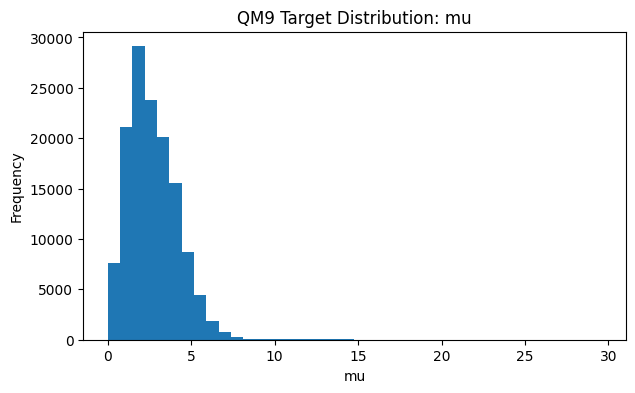

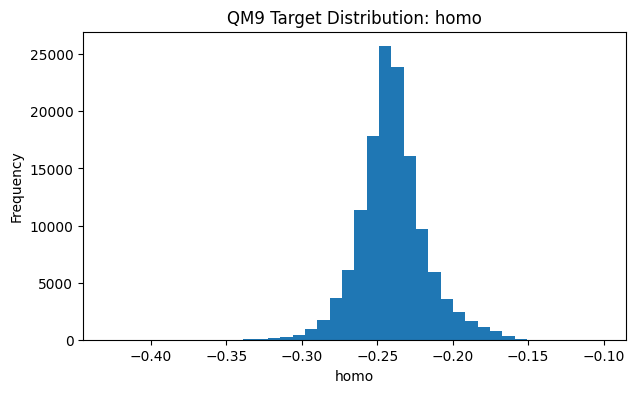

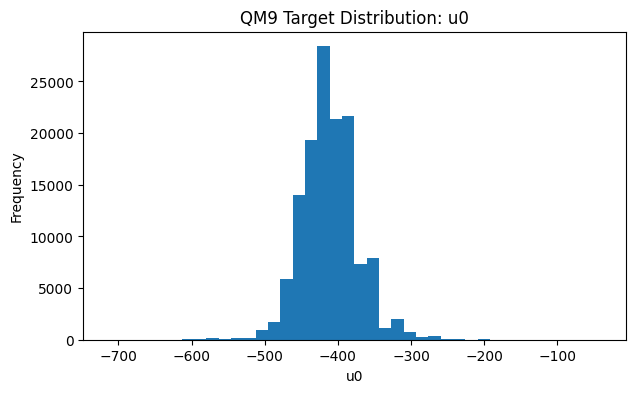

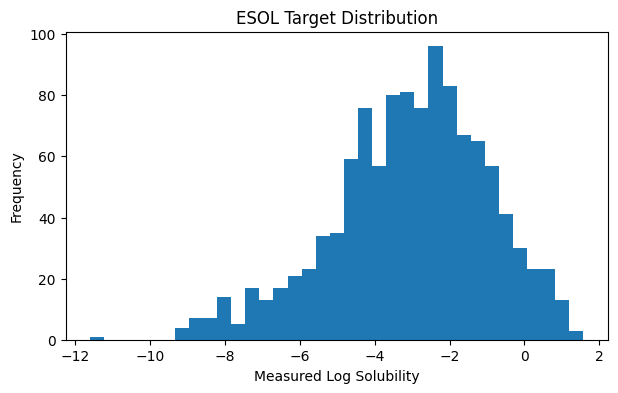

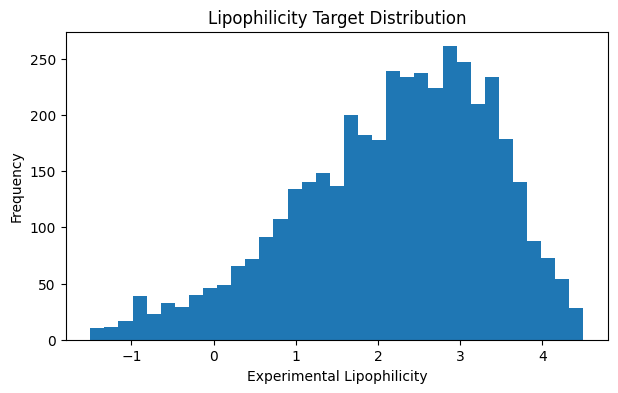

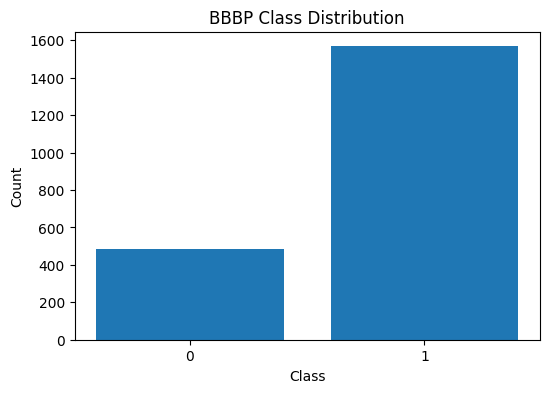

p_np
0     483
1    1567
Name: count, dtype: int64


In [11]:
# EDA: Target distributions
# QM9 targets
plt.figure(figsize=(7, 4))
plt.hist(qm9_df["mu"], bins=40)
plt.title("QM9 Target Distribution: mu")
plt.xlabel("mu")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(qm9_df["homo"], bins=40)
plt.title("QM9 Target Distribution: homo")
plt.xlabel("homo")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(qm9_df["u0"], bins=40)
plt.title("QM9 Target Distribution: u0")
plt.xlabel("u0")
plt.ylabel("Frequency")
plt.show()

# ESOL target
plt.figure(figsize=(7, 4))
plt.hist(esol_df["measured log solubility in mols per litre"], bins=35)
plt.title("ESOL Target Distribution")
plt.xlabel("Measured Log Solubility")
plt.ylabel("Frequency")
plt.show()

# Lipophilicity target
plt.figure(figsize=(7, 4))
plt.hist(lipo_df["exp"], bins=35)
plt.title("Lipophilicity Target Distribution")
plt.xlabel("Experimental Lipophilicity")
plt.ylabel("Frequency")
plt.show()

# BBBP class distribution
class_counts = bbbp_df["p_np"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("BBBP Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(class_counts)

In [13]:
# EDA: Molecular statistics from SMILES
def smiles_statistics(smiles_series):
    atom_counts = []
    bond_counts = []
    mol_weights = []

    for smi in tqdm(smiles_series):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            continue
        atom_counts.append(mol.GetNumAtoms())
        bond_counts.append(mol.GetNumBonds())
        mol_weights.append(Descriptors.MolWt(mol))

    return pd.DataFrame({
        "num_atoms": atom_counts,
        "num_bonds": bond_counts,
        "mol_weight": mol_weights
    })

    qm9_stats = smiles_statistics(qm9_df["smiles"].sample(5000, random_state=SEED))
esol_stats = smiles_statistics(esol_df["smiles"])
lipo_stats = smiles_statistics(lipo_df["smiles"])
bbbp_stats = smiles_statistics(bbbp_df["smiles"])

  3%|▎         | 60/2050 [00:00<00:04, 401.57it/s][14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
 25%|██▍       | 505/2050 [00:00<00:00, 2379.43it/s][14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] WARNING: not removing hydrogen atom without neighbors
[14:03:11] Explicit valence for atom 

In [14]:
# Define atom and bond encodings
ATOM_LIST = ["H", "C", "N", "O", "F", "P", "S", "Cl", "Br", "I"]

HYBRIDIZATION_LIST = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

BOND_TYPES = {
    Chem.rdchem.BondType.SINGLE: 0,
    Chem.rdchem.BondType.DOUBLE: 1,
    Chem.rdchem.BondType.TRIPLE: 2,
    Chem.rdchem.BondType.AROMATIC: 3,
}

In [17]:
# Helper functions for graph features
def one_hot_with_unknown(value, choices):
    encoding = [0] * (len(choices) + 1)
    try:
        encoding[choices.index(value)] = 1
    except ValueError:
        encoding[-1] = 1
    return encoding
def atom_features(atom):
    features = (
        one_hot_with_unknown(atom.GetSymbol(), ATOM_LIST) +
        one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATION_LIST) +
        [
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            atom.GetNumRadicalElectrons(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            atom.GetTotalNumHs()
        ]
    )
    return torch.tensor(features, dtype=torch.float)
def bond_features(bond):
    bt = bond.GetBondType()
    feat = [0, 0, 0, 0]
    feat[BOND_TYPES.get(bt, 0)] = 1
    feat += [int(bond.GetIsConjugated()), int(bond.IsInRing())]
    return feat

In [18]:
# Convert SMILES to graph
def smiles_to_graph(smiles, y, task_type="regression"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    edge_indices = []
    edge_attrs = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_features(bond)

        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bf, bf]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)

    if task_type == "regression":
        y_tensor = torch.tensor([float(y)], dtype=torch.float)
    else:
        y_tensor = torch.tensor([int(y)], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_tensor, smiles=smiles)

In [19]:
# Build graph datasets
def build_graph_dataset(df, smiles_col, target_col, task_type="regression", max_samples=None):
    if max_samples is not None:
        df = df.sample(min(max_samples, len(df)), random_state=SEED).reset_index(drop=True)

    data_list = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        graph = smiles_to_graph(row[smiles_col], row[target_col], task_type=task_type)
        if graph is not None:
            data_list.append(graph)

    return data_list

In [20]:
qm9_mu_graphs = build_graph_dataset(qm9_df, "smiles", "mu", task_type="regression", max_samples=20000)
qm9_homo_graphs = build_graph_dataset(qm9_df, "smiles", "homo", task_type="regression", max_samples=20000)
qm9_u0_graphs = build_graph_dataset(qm9_df, "smiles", "u0", task_type="regression", max_samples=20000)

esol_graphs = build_graph_dataset(esol_df, "smiles", "measured log solubility in mols per litre", task_type="regression")
lipo_graphs = build_graph_dataset(lipo_df, "smiles", "exp", task_type="regression")
bbbp_graphs = build_graph_dataset(bbbp_df, "smiles", "p_np", task_type="classification")

print("QM9 mu graphs:", len(qm9_mu_graphs))
print("QM9 homo graphs:", len(qm9_homo_graphs))
print("QM9 u0 graphs:", len(qm9_u0_graphs))
print("ESOL graphs:", len(esol_graphs))
print("Lipophilicity graphs:", len(lipo_graphs))
print("BBBP graphs:", len(bbbp_graphs))

  2%|▏         | 39/2050 [00:00<00:05, 387.20it/s][14:07:39] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:07:39] WARNING: not removing hydrogen atom without neighbors
[14:07:39] Explicit valence for atom # 6 N, 4, is greater than permitted
 14%|█▍        | 288/2050 [00:00<00:04, 362.45it/s][14:07:40] WARNING: not removing hydrogen atom without neighbors
[14:07:40] WARNING: not removing hydrogen atom without neighbors
[14:07:40] WARNING: not removing hydrogen atom without neighbors
 21%|██▏       | 440/2050 [00:01<00:04, 362.74it/s][14:07:40] WARNING: not removing hydrogen atom without neighbors
[14:07:40] WARNING: not removing hydrogen atom without neighbors
 28%|██▊       | 574/2050 [00:01<00:03, 413.50it/s][14:07:40] WARNING: not removing hydrogen atom without neighbors
[14:07:40] Explicit valence for atom # 11 N, 4, is greater than permitted
 30%|███       | 616/2050 [00:01<00:03, 400.05it/s][14:07:41] Explicit valence for atom # 12 N, 4, is greater than permitt

QM9 mu graphs: 20000
QM9 homo graphs: 20000
QM9 u0 graphs: 20000
ESOL graphs: 1128
Lipophilicity graphs: 4200
BBBP graphs: 2039


In [23]:
# Train/validation/test split
def split_graphs(graphs, val_size=0.1, test_size=0.1, seed=SEED):
    indices = np.arange(len(graphs))
    train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=seed)
    train_idx, val_idx = train_test_split(train_idx, test_size=val_size/(1-test_size), random_state=seed)

    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]

    return train_graphs, val_graphs, test_graphs

def make_loaders(graphs, batch_size=64):
    train_graphs, val_graphs, test_graphs = split_graphs(graphs)
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

qm9_mu_loaders = make_loaders(qm9_mu_graphs, batch_size=128)
qm9_homo_loaders = make_loaders(qm9_homo_graphs, batch_size=128)
qm9_u0_loaders = make_loaders(qm9_u0_graphs, batch_size=128)

esol_loaders = make_loaders(esol_graphs, batch_size=64)
lipo_loaders = make_loaders(lipo_graphs, batch_size=64)
bbbp_loaders = make_loaders(bbbp_graphs, batch_size=64)

In [24]:
# Baseline GCN model for regression
class GCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x.squeeze(-1)

In [25]:
# Baseline GCN model for classification
class GCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 2)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x

In [26]:
# Edge-aware attention layer
class EdgeAwareAttentionConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim=6):
        super().__init__(aggr="add")
        self.lin_node = nn.Linear(in_channels, out_channels)
        self.lin_edge = nn.Linear(edge_dim, out_channels)
        self.att = nn.Linear(3 * out_channels, 1)

    def forward(self, x, edge_index, edge_attr):
        x = self.lin_node(x)
        e = self.lin_edge(edge_attr)
        return self.propagate(edge_index, x=x, edge_attr=e)

    def message(self, x_i, x_j, edge_attr, index):
        att_input = torch.cat([x_i, x_j, edge_attr], dim=-1)
        alpha = self.att(att_input)
        alpha = F.leaky_relu(alpha, 0.2)
        alpha = softmax(alpha, index)
        return x_j * alpha

In [27]:
# Attention GCN for regression
class AttentionGCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, edge_dim=6, dropout=0.2):
        super().__init__()
        self.conv1 = EdgeAwareAttentionConv(in_channels, hidden_channels, edge_dim=edge_dim)
        self.conv2 = EdgeAwareAttentionConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x.squeeze(-1)

In [28]:
# Attention GCN for classification
class AttentionGCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, edge_dim=6, dropout=0.2):
        super().__init__()
        self.conv1 = EdgeAwareAttentionConv(in_channels, hidden_channels, edge_dim=edge_dim)
        self.conv2 = EdgeAwareAttentionConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 2)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x

In [29]:
# Training function for regression
def train_regression(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        if isinstance(model, AttentionGCNRegressor):
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        else:
            out = model(batch.x, batch.edge_index, batch.batch)

        loss = criterion(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [37]:
# Evaluation function for regression
def eval_regression(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            if isinstance(model, AttentionGCNRegressor):
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            else:
                out = model(batch.x, batch.edge_index, batch.batch)

            preds.extend(out.cpu().numpy())
            trues.extend(batch.y.view(-1).cpu().numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    mse = mean_squared_error(trues, preds) # Calculate MSE first
    rmse = np.sqrt(mse) # Then calculate RMSE

    return {
        "MAE": mean_absolute_error(trues, preds),
        "RMSE": rmse,
        "R2": r2_score(trues, preds),
        "y_true": trues,
        "y_pred": preds
    }

In [31]:
# Training function for classification
def train_classification(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        if isinstance(model, AttentionGCNClassifier):
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        else:
            logits = model(batch.x, batch.edge_index, batch.batch)

        loss = criterion(logits, batch.y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [32]:
# Evaluation function for classification
def eval_classification(model, loader):
    model.eval()
    probs_all, preds_all, trues_all = [], [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            if isinstance(model, AttentionGCNClassifier):
                logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            else:
                logits = model(batch.x, batch.edge_index, batch.batch)

            probs = F.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)

            probs_all.extend(probs.cpu().numpy())
            preds_all.extend(preds.cpu().numpy())
            trues_all.extend(batch.y.view(-1).cpu().numpy())

    probs_all = np.array(probs_all)
    preds_all = np.array(preds_all)
    trues_all = np.array(trues_all)

    return {
        "Accuracy": accuracy_score(trues_all, preds_all),
        "Precision": precision_score(trues_all, preds_all),
        "Recall": recall_score(trues_all, preds_all),
        "F1": f1_score(trues_all, preds_all),
        "ROC_AUC": roc_auc_score(trues_all, probs_all),
        "y_true": trues_all,
        "y_pred": preds_all,
        "y_prob": probs_all
    }

In [33]:
# Full training loop for regression
def fit_regression_model(model, loaders, epochs=30, lr=1e-3):
    train_loader, val_loader, test_loader = loaders
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_rmse": []}
    best_state = None
    best_rmse = np.inf

    for epoch in range(1, epochs + 1):
        train_loss = train_regression(model, train_loader, optimizer, criterion)
        val_metrics = eval_regression(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_rmse"].append(val_metrics["RMSE"])

        if val_metrics["RMSE"] < best_rmse:
            best_rmse = val_metrics["RMSE"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val RMSE: {val_metrics['RMSE']:.4f}")

    model.load_state_dict(best_state)
    test_metrics = eval_regression(model, test_loader)

    return model, history, test_metrics

In [34]:
# Full training loop for classification
def fit_classification_model(model, loaders, epochs=30, lr=1e-3):
    train_loader, val_loader, test_loader = loaders
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_auc": []}
    best_state = None
    best_auc = -np.inf

    for epoch in range(1, epochs + 1):
        train_loss = train_classification(model, train_loader, optimizer, criterion)
        val_metrics = eval_classification(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_metrics["ROC_AUC"])

        if val_metrics["ROC_AUC"] > best_auc:
            best_auc = val_metrics["ROC_AUC"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val AUC: {val_metrics['ROC_AUC']:.4f}")

    model.load_state_dict(best_state)
    test_metrics = eval_classification(model, test_loader)

    return model, history, test_metrics

In [35]:
# Check input dimensions
sample_graph = qm9_mu_graphs[0]
in_channels = sample_graph.x.shape[1]
edge_dim = sample_graph.edge_attr.shape[1]

print("Node feature dimension:", in_channels)
print("Edge feature dimension:", edge_dim)

Node feature dimension: 24
Edge feature dimension: 6


In [38]:
# Train baseline and attention models on QM9 mu
baseline_qm9_mu = GCNRegressor(in_channels)
attention_qm9_mu = AttentionGCNRegressor(in_channels, edge_dim=edge_dim)

baseline_qm9_mu, hist_base_mu, test_base_mu = fit_regression_model(
    baseline_qm9_mu, qm9_mu_loaders, epochs=25
)

attention_qm9_mu, hist_attn_mu, test_attn_mu = fit_regression_model(
    attention_qm9_mu, qm9_mu_loaders, epochs=25
)

print("Baseline QM9 mu:", test_base_mu)
print("Attention QM9 mu:", test_attn_mu)

Epoch 001 | Train Loss: 2.7454 | Val RMSE: 1.3739
Epoch 002 | Train Loss: 1.8935 | Val RMSE: 1.3221
Epoch 003 | Train Loss: 1.7790 | Val RMSE: 1.2976
Epoch 004 | Train Loss: 1.6739 | Val RMSE: 1.2246
Epoch 005 | Train Loss: 1.5786 | Val RMSE: 1.1902
Epoch 006 | Train Loss: 1.5059 | Val RMSE: 1.1445
Epoch 007 | Train Loss: 1.4909 | Val RMSE: 1.1283
Epoch 008 | Train Loss: 1.4586 | Val RMSE: 1.1130
Epoch 009 | Train Loss: 1.3898 | Val RMSE: 1.0955
Epoch 010 | Train Loss: 1.3841 | Val RMSE: 1.0816
Epoch 011 | Train Loss: 1.3494 | Val RMSE: 1.0969
Epoch 012 | Train Loss: 1.3356 | Val RMSE: 1.0623
Epoch 013 | Train Loss: 1.3358 | Val RMSE: 1.0675
Epoch 014 | Train Loss: 1.3033 | Val RMSE: 1.0570
Epoch 015 | Train Loss: 1.2822 | Val RMSE: 1.0763
Epoch 016 | Train Loss: 1.2806 | Val RMSE: 1.0529
Epoch 017 | Train Loss: 1.2894 | Val RMSE: 1.0700
Epoch 018 | Train Loss: 1.2778 | Val RMSE: 1.0709
Epoch 019 | Train Loss: 1.2637 | Val RMSE: 1.0540
Epoch 020 | Train Loss: 1.2658 | Val RMSE: 1.0676


In [39]:
# Train on QM9 homo
baseline_qm9_homo = GCNRegressor(in_channels)
attention_qm9_homo = AttentionGCNRegressor(in_channels, edge_dim=edge_dim)

baseline_qm9_homo, hist_base_homo, test_base_homo = fit_regression_model(
    baseline_qm9_homo, qm9_homo_loaders, epochs=25
)

attention_qm9_homo, hist_attn_homo, test_attn_homo = fit_regression_model(
    attention_qm9_homo, qm9_homo_loaders, epochs=25
)

print("Baseline QM9 homo:", test_base_homo)
print("Attention QM9 homo:", test_attn_homo)

Epoch 001 | Train Loss: 0.0034 | Val RMSE: 0.0220
Epoch 002 | Train Loss: 0.0013 | Val RMSE: 0.0201
Epoch 003 | Train Loss: 0.0010 | Val RMSE: 0.0197
Epoch 004 | Train Loss: 0.0008 | Val RMSE: 0.0179
Epoch 005 | Train Loss: 0.0007 | Val RMSE: 0.0203
Epoch 006 | Train Loss: 0.0006 | Val RMSE: 0.0196
Epoch 007 | Train Loss: 0.0005 | Val RMSE: 0.0168
Epoch 008 | Train Loss: 0.0004 | Val RMSE: 0.0147
Epoch 009 | Train Loss: 0.0004 | Val RMSE: 0.0156
Epoch 010 | Train Loss: 0.0003 | Val RMSE: 0.0191
Epoch 011 | Train Loss: 0.0003 | Val RMSE: 0.0144
Epoch 012 | Train Loss: 0.0003 | Val RMSE: 0.0147
Epoch 013 | Train Loss: 0.0002 | Val RMSE: 0.0141
Epoch 014 | Train Loss: 0.0002 | Val RMSE: 0.0140
Epoch 015 | Train Loss: 0.0002 | Val RMSE: 0.0140
Epoch 016 | Train Loss: 0.0002 | Val RMSE: 0.0127
Epoch 017 | Train Loss: 0.0002 | Val RMSE: 0.0126
Epoch 018 | Train Loss: 0.0002 | Val RMSE: 0.0122
Epoch 019 | Train Loss: 0.0002 | Val RMSE: 0.0127
Epoch 020 | Train Loss: 0.0002 | Val RMSE: 0.0135


In [40]:
# Train on QM9 u0
baseline_qm9_u0 = GCNRegressor(in_channels)
attention_qm9_u0 = AttentionGCNRegressor(in_channels, edge_dim=edge_dim)

baseline_qm9_u0, hist_base_u0, test_base_u0 = fit_regression_model(
    baseline_qm9_u0, qm9_u0_loaders, epochs=25
)

attention_qm9_u0, hist_attn_u0, test_attn_u0 = fit_regression_model(
    attention_qm9_u0, qm9_u0_loaders, epochs=25
)

print("Baseline QM9 u0:", test_base_u0)
print("Attention QM9 u0:", test_attn_u0)

Epoch 001 | Train Loss: 71791.3096 | Val RMSE: 37.5918
Epoch 002 | Train Loss: 3217.1298 | Val RMSE: 35.2415
Epoch 003 | Train Loss: 2950.2494 | Val RMSE: 33.2490
Epoch 004 | Train Loss: 2796.7938 | Val RMSE: 30.5049
Epoch 005 | Train Loss: 2579.9302 | Val RMSE: 27.8968
Epoch 006 | Train Loss: 2502.5365 | Val RMSE: 26.0480
Epoch 007 | Train Loss: 2420.6795 | Val RMSE: 25.0120
Epoch 008 | Train Loss: 2401.4463 | Val RMSE: 24.5803
Epoch 009 | Train Loss: 2342.5929 | Val RMSE: 24.2861
Epoch 010 | Train Loss: 2352.8090 | Val RMSE: 24.0659
Epoch 011 | Train Loss: 2311.0025 | Val RMSE: 23.6984
Epoch 012 | Train Loss: 2331.2595 | Val RMSE: 23.8756
Epoch 013 | Train Loss: 2260.6909 | Val RMSE: 24.7729
Epoch 014 | Train Loss: 2271.8106 | Val RMSE: 24.8513
Epoch 015 | Train Loss: 2330.7235 | Val RMSE: 23.6711
Epoch 016 | Train Loss: 2334.3329 | Val RMSE: 24.8100
Epoch 017 | Train Loss: 2340.2114 | Val RMSE: 23.4219
Epoch 018 | Train Loss: 2318.7053 | Val RMSE: 24.6146
Epoch 019 | Train Loss: 226

In [41]:
# Train on ESOL
baseline_esol = GCNRegressor(in_channels)
attention_esol = AttentionGCNRegressor(in_channels, edge_dim=edge_dim)

baseline_esol, hist_base_esol, test_base_esol = fit_regression_model(
    baseline_esol, esol_loaders, epochs=35
)

attention_esol, hist_attn_esol, test_attn_esol = fit_regression_model(
    attention_esol, esol_loaders, epochs=35
)

print("Baseline ESOL:", test_base_esol)
print("Attention ESOL:", test_attn_esol)

Epoch 001 | Train Loss: 10.9280 | Val RMSE: 2.7274
Epoch 002 | Train Loss: 5.3313 | Val RMSE: 2.3561
Epoch 003 | Train Loss: 4.9404 | Val RMSE: 2.2183
Epoch 004 | Train Loss: 4.7759 | Val RMSE: 2.1205
Epoch 005 | Train Loss: 4.5118 | Val RMSE: 2.0921
Epoch 006 | Train Loss: 4.2781 | Val RMSE: 2.0431
Epoch 007 | Train Loss: 4.0757 | Val RMSE: 2.0016
Epoch 008 | Train Loss: 4.0256 | Val RMSE: 1.9688
Epoch 009 | Train Loss: 3.8973 | Val RMSE: 1.9560
Epoch 010 | Train Loss: 3.7621 | Val RMSE: 1.8778
Epoch 011 | Train Loss: 3.6277 | Val RMSE: 1.8811
Epoch 012 | Train Loss: 3.5920 | Val RMSE: 1.8737
Epoch 013 | Train Loss: 3.5181 | Val RMSE: 1.7901
Epoch 014 | Train Loss: 3.2054 | Val RMSE: 1.7520
Epoch 015 | Train Loss: 3.1100 | Val RMSE: 1.7111
Epoch 016 | Train Loss: 3.1418 | Val RMSE: 1.6887
Epoch 017 | Train Loss: 2.8503 | Val RMSE: 1.6926
Epoch 018 | Train Loss: 2.9935 | Val RMSE: 1.9073
Epoch 019 | Train Loss: 3.3903 | Val RMSE: 1.6573
Epoch 020 | Train Loss: 2.9418 | Val RMSE: 1.6063

In [42]:
# Train on Lipophilicity
baseline_lipo = GCNRegressor(in_channels)
attention_lipo = AttentionGCNRegressor(in_channels, edge_dim=edge_dim)

baseline_lipo, hist_base_lipo, test_base_lipo = fit_regression_model(
    baseline_lipo, lipo_loaders, epochs=35
)

attention_lipo, hist_attn_lipo, test_attn_lipo = fit_regression_model(
    attention_lipo, lipo_loaders, epochs=35
)

print("Baseline Lipophilicity:", test_base_lipo)
print("Attention Lipophilicity:", test_attn_lipo)

Epoch 001 | Train Loss: 2.1598 | Val RMSE: 1.1399
Epoch 002 | Train Loss: 1.5423 | Val RMSE: 1.1508
Epoch 003 | Train Loss: 1.5156 | Val RMSE: 1.1351
Epoch 004 | Train Loss: 1.5246 | Val RMSE: 1.1466
Epoch 005 | Train Loss: 1.4897 | Val RMSE: 1.1169
Epoch 006 | Train Loss: 1.4770 | Val RMSE: 1.1079
Epoch 007 | Train Loss: 1.4949 | Val RMSE: 1.1042
Epoch 008 | Train Loss: 1.4371 | Val RMSE: 1.1051
Epoch 009 | Train Loss: 1.4209 | Val RMSE: 1.1182
Epoch 010 | Train Loss: 1.3957 | Val RMSE: 1.1266
Epoch 011 | Train Loss: 1.3729 | Val RMSE: 1.1005
Epoch 012 | Train Loss: 1.3909 | Val RMSE: 1.0943
Epoch 013 | Train Loss: 1.3646 | Val RMSE: 1.0936
Epoch 014 | Train Loss: 1.3490 | Val RMSE: 1.0809
Epoch 015 | Train Loss: 1.3295 | Val RMSE: 1.1162
Epoch 016 | Train Loss: 1.3280 | Val RMSE: 1.0868
Epoch 017 | Train Loss: 1.3174 | Val RMSE: 1.0694
Epoch 018 | Train Loss: 1.2889 | Val RMSE: 1.0642
Epoch 019 | Train Loss: 1.3068 | Val RMSE: 1.0709
Epoch 020 | Train Loss: 1.2674 | Val RMSE: 1.0658


In [43]:
# Train on BBBP classification
baseline_bbbp = GCNClassifier(in_channels)
attention_bbbp = AttentionGCNClassifier(in_channels, edge_dim=edge_dim)

baseline_bbbp, hist_base_bbbp, test_base_bbbp = fit_classification_model(
    baseline_bbbp, bbbp_loaders, epochs=35
)

attention_bbbp, hist_attn_bbbp, test_attn_bbbp = fit_classification_model(
    attention_bbbp, bbbp_loaders, epochs=35
)

print("Baseline BBBP:", test_base_bbbp)
print("Attention BBBP:", test_attn_bbbp)

Epoch 001 | Train Loss: 0.5685 | Val AUC: 0.4635
Epoch 002 | Train Loss: 0.5448 | Val AUC: 0.6024
Epoch 003 | Train Loss: 0.5407 | Val AUC: 0.6619
Epoch 004 | Train Loss: 0.5329 | Val AUC: 0.6830
Epoch 005 | Train Loss: 0.5238 | Val AUC: 0.6811
Epoch 006 | Train Loss: 0.5067 | Val AUC: 0.6869
Epoch 007 | Train Loss: 0.4933 | Val AUC: 0.6919
Epoch 008 | Train Loss: 0.4737 | Val AUC: 0.6983
Epoch 009 | Train Loss: 0.4748 | Val AUC: 0.7055
Epoch 010 | Train Loss: 0.4733 | Val AUC: 0.7055
Epoch 011 | Train Loss: 0.4625 | Val AUC: 0.7091
Epoch 012 | Train Loss: 0.4570 | Val AUC: 0.7131
Epoch 013 | Train Loss: 0.4506 | Val AUC: 0.7162
Epoch 014 | Train Loss: 0.4502 | Val AUC: 0.7151
Epoch 015 | Train Loss: 0.4653 | Val AUC: 0.7129
Epoch 016 | Train Loss: 0.4581 | Val AUC: 0.7199
Epoch 017 | Train Loss: 0.4511 | Val AUC: 0.7179
Epoch 018 | Train Loss: 0.4540 | Val AUC: 0.7229
Epoch 019 | Train Loss: 0.4486 | Val AUC: 0.7232
Epoch 020 | Train Loss: 0.4473 | Val AUC: 0.7163
Epoch 021 | Train Lo

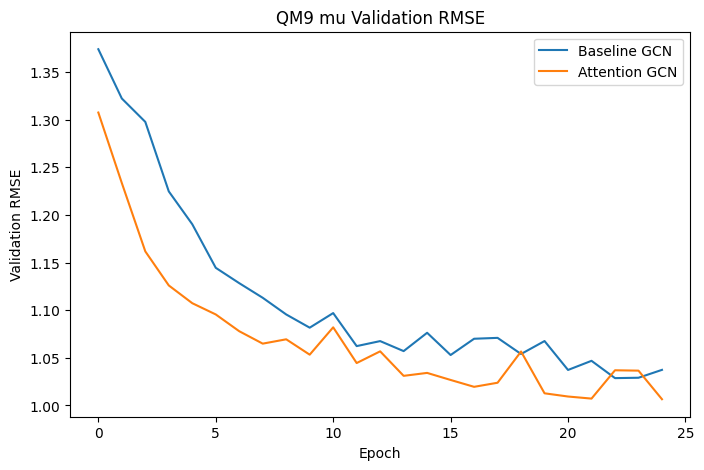

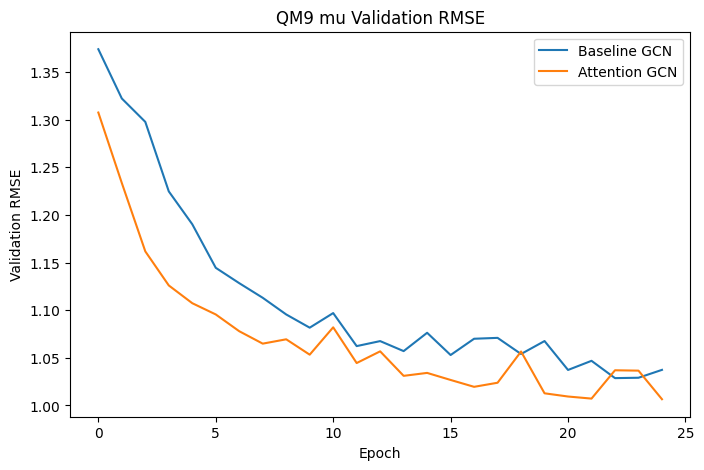

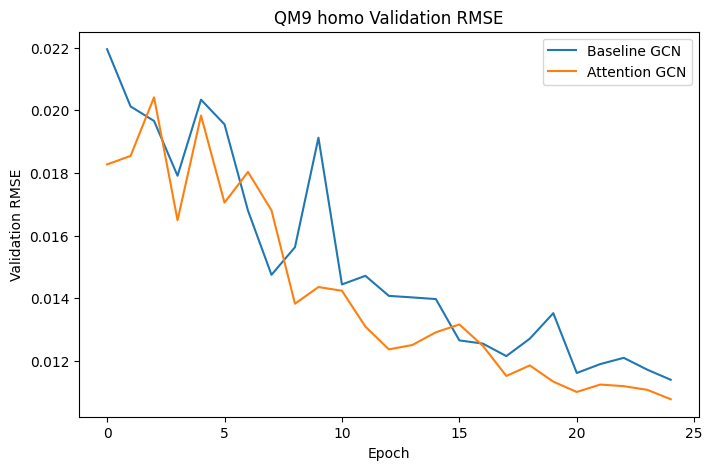

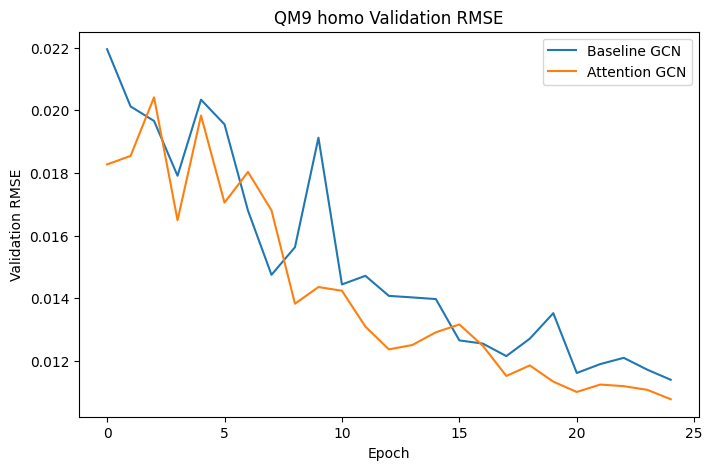

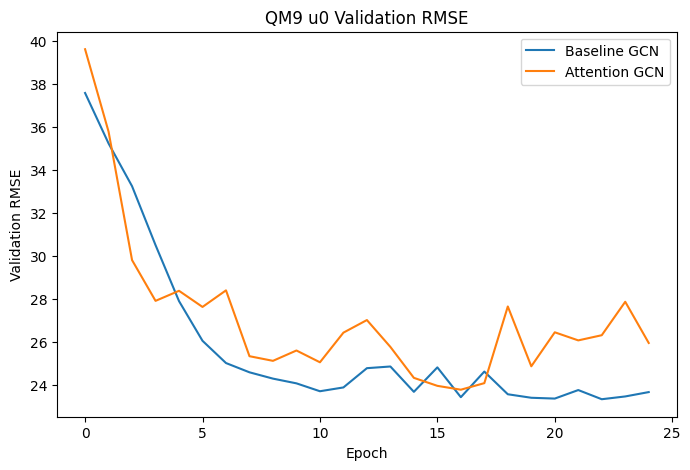

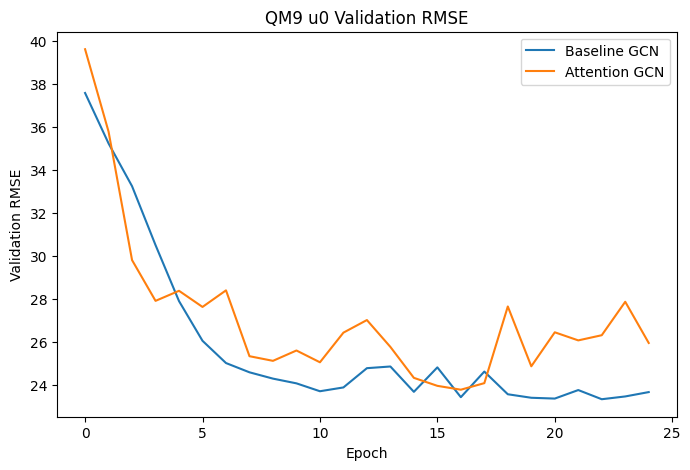

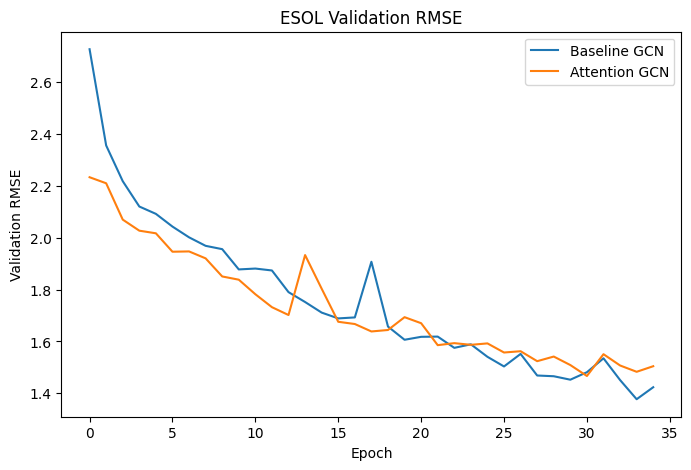

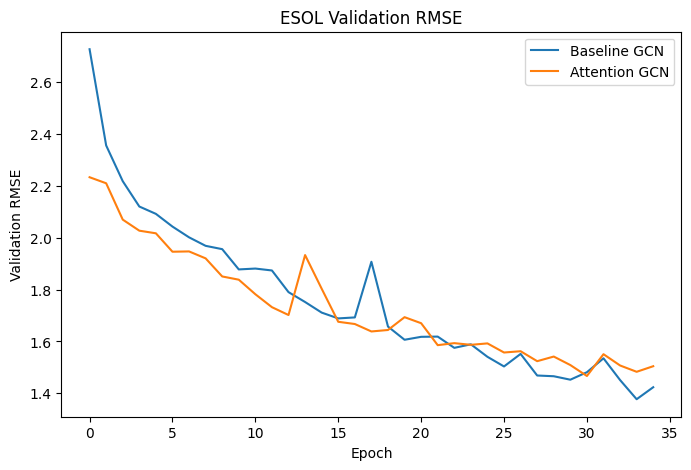

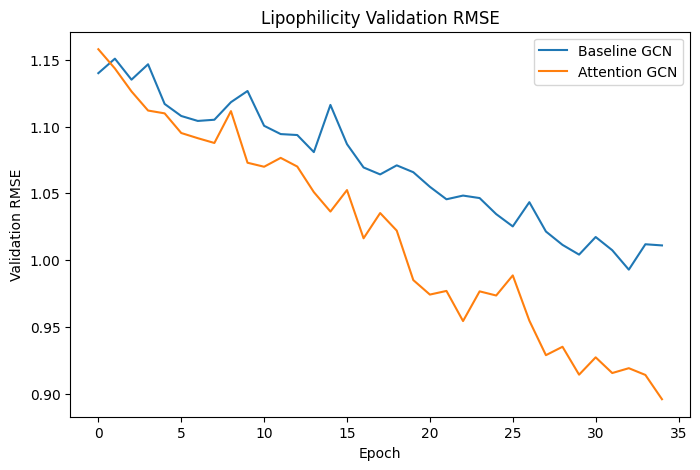

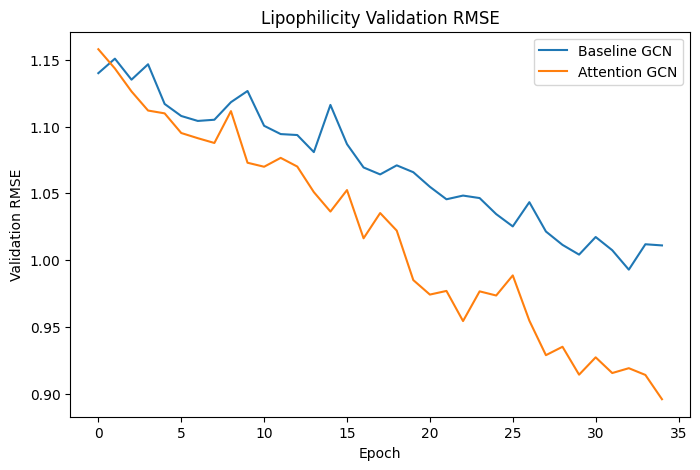

In [55]:
# Plot training curves for regression
def plot_regression_history(hist_base, hist_attn, title):
    fig = plt.figure(figsize=(8, 5))
    plt.plot(hist_base["val_rmse"], label="Baseline GCN")
    plt.plot(hist_attn["val_rmse"], label="Attention GCN")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Validation RMSE")
    plt.legend()
    plt.show()
    return fig

display(plot_regression_history(hist_base_mu, hist_attn_mu, "QM9 mu Validation RMSE"))
display(plot_regression_history(hist_base_homo, hist_attn_homo, "QM9 homo Validation RMSE"))
display(plot_regression_history(hist_base_u0, hist_attn_u0, "QM9 u0 Validation RMSE"))
display(plot_regression_history(hist_base_esol, hist_attn_esol, "ESOL Validation RMSE"))
display(plot_regression_history(hist_base_lipo, hist_attn_lipo, "Lipophilicity Validation RMSE"))

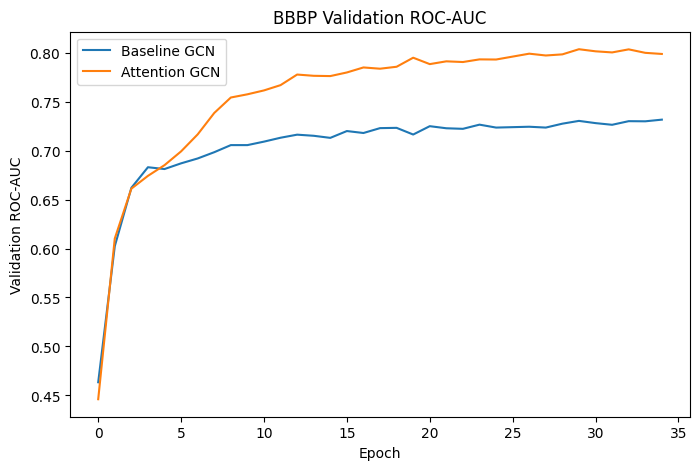

In [53]:
# Plot training curve for BBBP classification
def plot_classification_history(hist_base, hist_attn, title):
    plt.figure(figsize=(8, 5))
    plt.plot(hist_base["val_auc"], label="Baseline GCN")
    plt.plot(hist_attn["val_auc"], label="Attention GCN")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Validation ROC-AUC")
    plt.legend()
    plt.show()

plot_classification_history(hist_base_bbbp, hist_attn_bbbp, "BBBP Validation ROC-AUC")

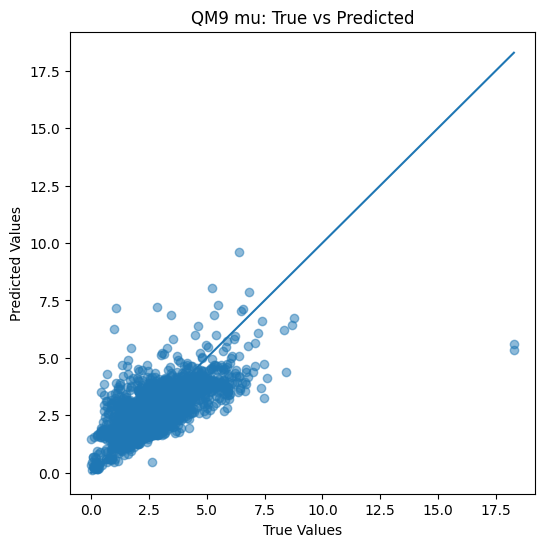

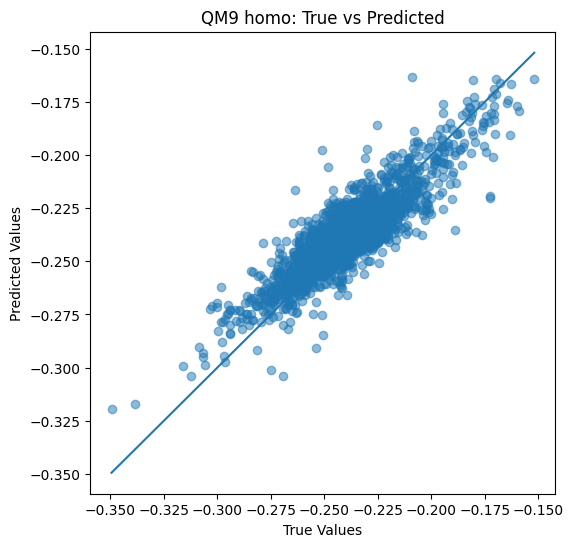

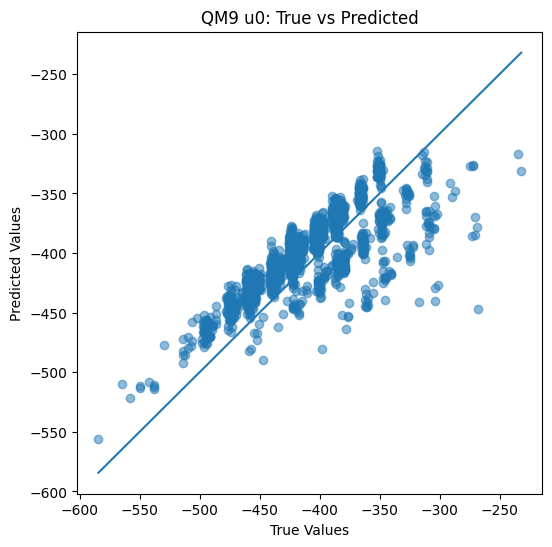

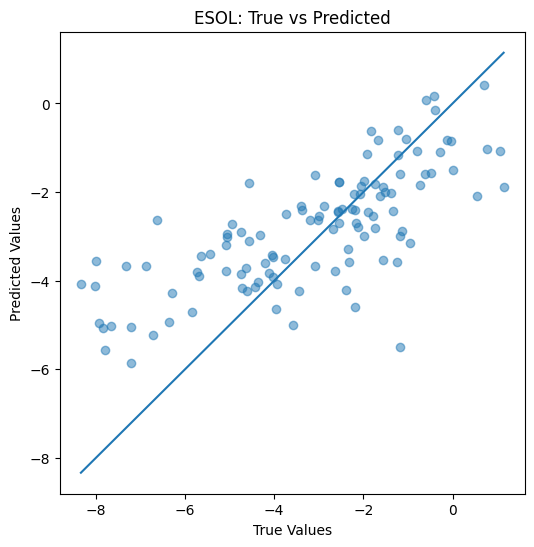

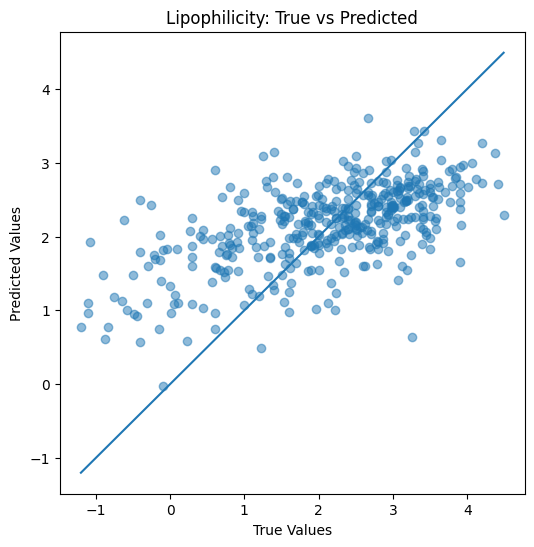

In [56]:
# Regression prediction scatter plots
def plot_regression_predictions(metrics, title):
    y_true = metrics["y_true"]
    y_pred = metrics["y_pred"]

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx])
    plt.title(title)
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.show()

plot_regression_predictions(test_attn_mu, "QM9 mu: True vs Predicted")
plot_regression_predictions(test_attn_homo, "QM9 homo: True vs Predicted")
plot_regression_predictions(test_attn_u0, "QM9 u0: True vs Predicted")
plot_regression_predictions(test_attn_esol, "ESOL: True vs Predicted")
plot_regression_predictions(test_attn_lipo, "Lipophilicity: True vs Predicted")

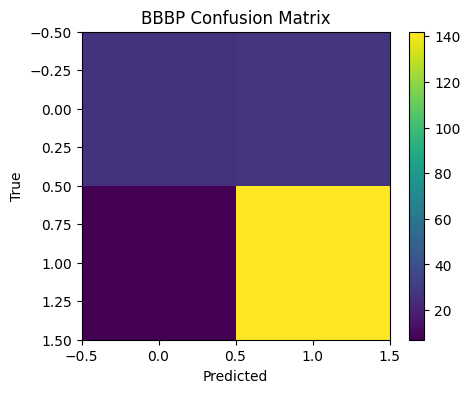

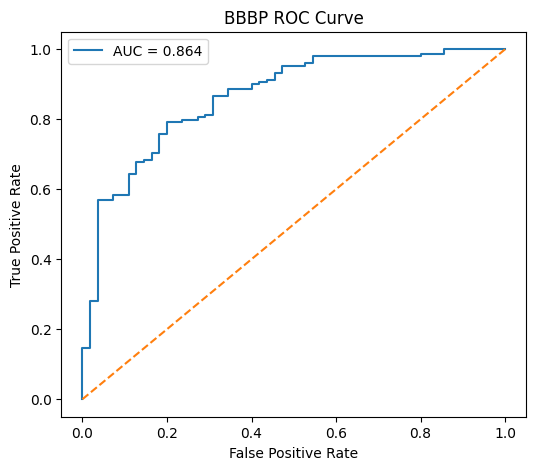

In [60]:
# Confusion matrix and ROC curve for BBBP
def plot_confusion_and_roc(metrics, title_prefix="BBBP"):
    cm = confusion_matrix(metrics["y_true"], metrics["y_pred"])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    fpr, tpr, _ = roc_curve(metrics["y_true"], metrics["y_prob"])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['ROC_AUC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{title_prefix} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

plot_confusion_and_roc(test_attn_bbbp)

In [61]:
# Final results table for regression
results_reg = pd.DataFrame([
    ["QM9-mu", "Baseline GCN", test_base_mu["RMSE"], test_base_mu["MAE"], test_base_mu["R2"]],
    ["QM9-mu", "Attention GCN", test_attn_mu["RMSE"], test_attn_mu["MAE"], test_attn_mu["R2"]],
    ["QM9-homo", "Baseline GCN", test_base_homo["RMSE"], test_base_homo["MAE"], test_base_homo["R2"]],
    ["QM9-homo", "Attention GCN", test_attn_homo["RMSE"], test_attn_homo["MAE"], test_attn_homo["R2"]],
    ["QM9-u0", "Baseline GCN", test_base_u0["RMSE"], test_base_u0["MAE"], test_base_u0["R2"]],
    ["QM9-u0", "Attention GCN", test_attn_u0["RMSE"], test_attn_u0["MAE"], test_attn_u0["R2"]],
    ["ESOL", "Baseline GCN", test_base_esol["RMSE"], test_base_esol["MAE"], test_base_esol["R2"]],
    ["ESOL", "Attention GCN", test_attn_esol["RMSE"], test_attn_esol["MAE"], test_attn_esol["R2"]],
    ["Lipophilicity", "Baseline GCN", test_base_lipo["RMSE"], test_base_lipo["MAE"], test_base_lipo["R2"]],
    ["Lipophilicity", "Attention GCN", test_attn_lipo["RMSE"], test_attn_lipo["MAE"], test_attn_lipo["R2"]],
], columns=["Dataset", "Model", "RMSE", "MAE", "R2"])

results_reg

,Dataset,Model,RMSE,MAE,R2
0,QM9-mu,Baseline GCN,1.039477,0.745278,0.529415
1,QM9-mu,Attention GCN,1.055133,0.726887,0.515133
2,QM9-homo,Baseline GCN,0.011254,0.008717,0.743558
3,QM9-homo,Attention GCN,0.010719,0.008282,0.767377
4,QM9-u0,Baseline GCN,24.883265,18.671246,0.632152
5,QM9-u0,Attention GCN,26.926980,22.552290,0.569247
6,ESOL,Baseline GCN,1.511233,1.151923,0.563078
7,ESOL,Attention GCN,1.619542,1.242910,0.498206
8,Lipophilicity,Baseline GCN,1.010298,0.836160,0.270134
9,Lipophilicity,Attention GCN,0.956089,0.762559,0.346357


In [62]:
# Final results table for classification
results_cls = pd.DataFrame([
    ["BBBP", "Baseline GCN", test_base_bbbp["Accuracy"], test_base_bbbp["Precision"], test_base_bbbp["Recall"], test_base_bbbp["F1"], test_base_bbbp["ROC_AUC"]],
    ["BBBP", "Attention GCN", test_attn_bbbp["Accuracy"], test_attn_bbbp["Precision"], test_attn_bbbp["Recall"], test_attn_bbbp["F1"], test_attn_bbbp["ROC_AUC"]],
], columns=["Dataset", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])

results_cls

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,BBBP,Baseline GCN,0.808824,0.835366,0.919463,0.875399,0.794753
1,BBBP,Attention GCN,0.828431,0.835294,0.953020,0.890282,0.864430


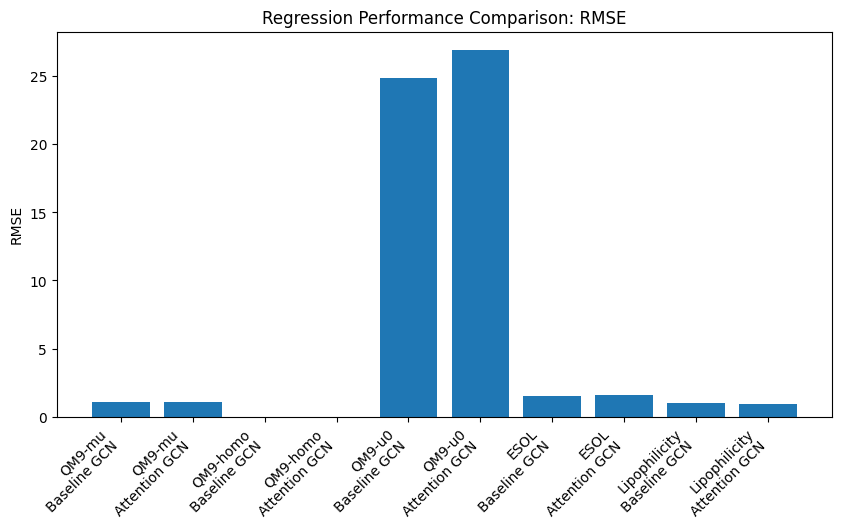

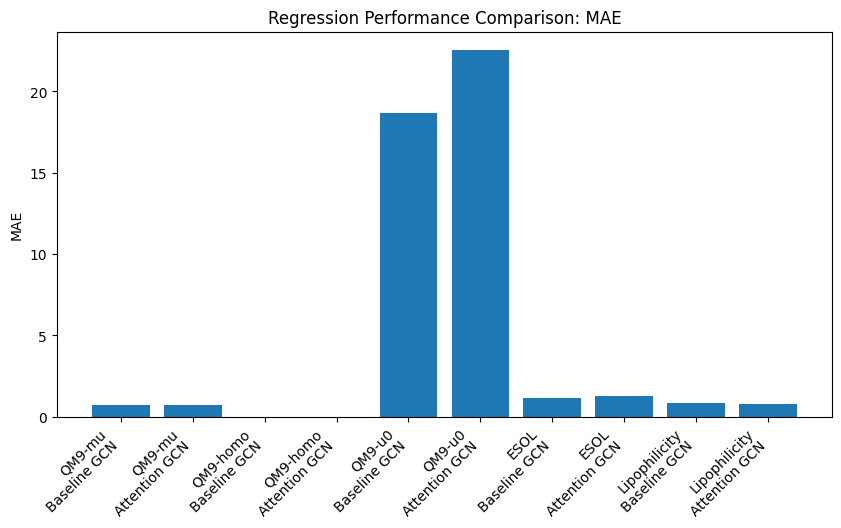

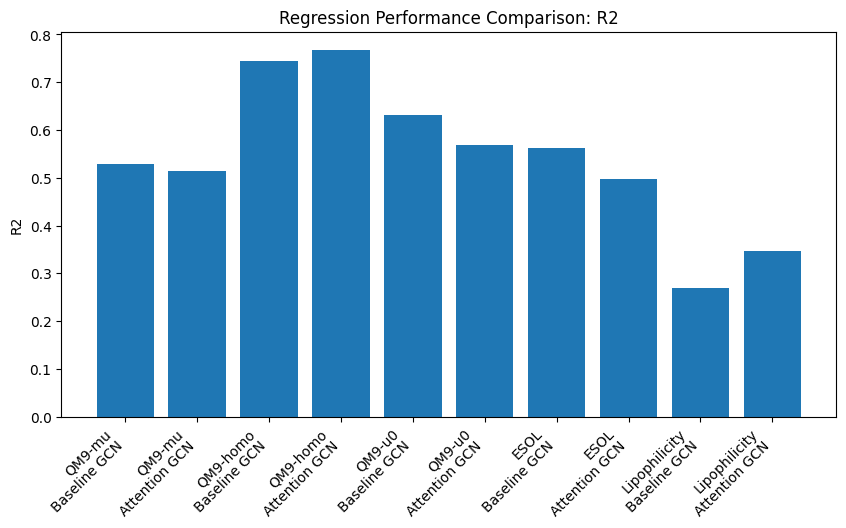

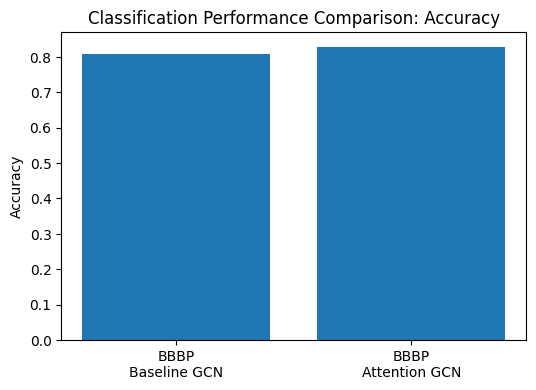

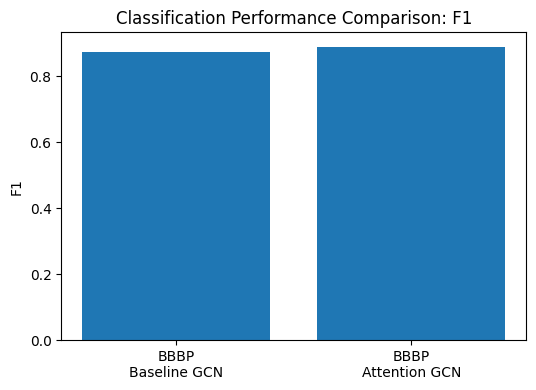

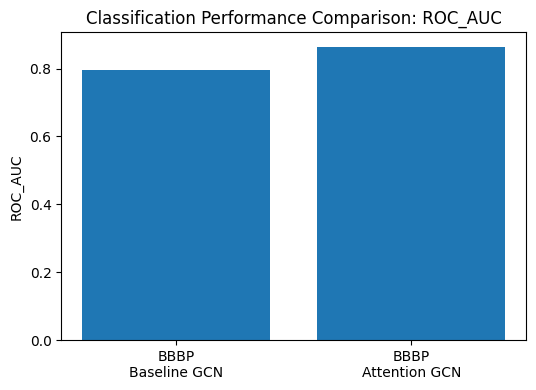

In [64]:
# Performance comparison bar plots
for metric in ["RMSE", "MAE", "R2"]:
    plt.figure(figsize=(10, 5))
    labels = [f"{d}\n{m}" for d, m in zip(results_reg["Dataset"], results_reg["Model"])]
    plt.bar(labels, results_reg[metric])
    plt.title(f"Regression Performance Comparison: {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.show()

for metric in ["Accuracy", "F1", "ROC_AUC"]:
    plt.figure(figsize=(6, 4))
    labels = [f"{d}\n{m}" for d, m in zip(results_cls["Dataset"], results_cls["Model"])]
    plt.bar(labels, results_cls[metric])
    plt.title(f"Classification Performance Comparison: {metric}")
    plt.ylabel(metric)
    plt.show()

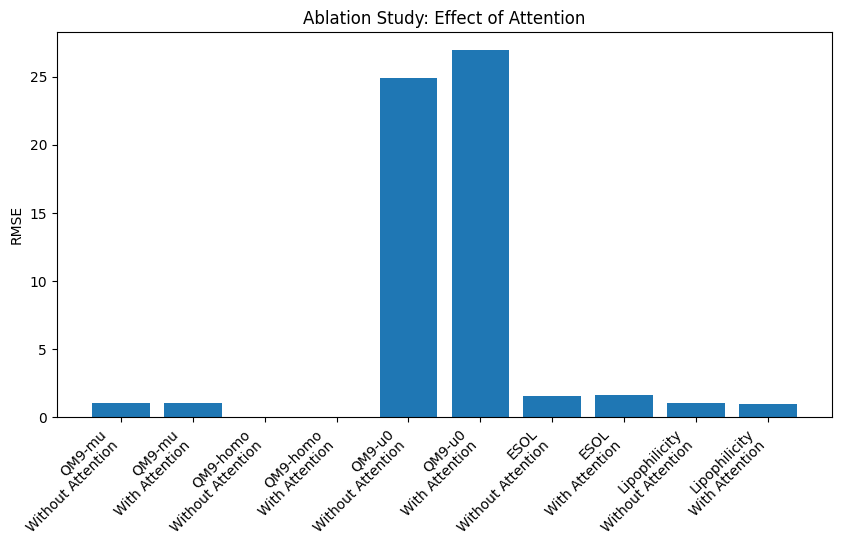

In [65]:
# Ablation study: with vs without attention
ablation_results = pd.DataFrame([
    ["QM9-mu", "Without Attention", test_base_mu["RMSE"]],
    ["QM9-mu", "With Attention", test_attn_mu["RMSE"]],
    ["QM9-homo", "Without Attention", test_base_homo["RMSE"]],
    ["QM9-homo", "With Attention", test_attn_homo["RMSE"]],
    ["QM9-u0", "Without Attention", test_base_u0["RMSE"]],
    ["QM9-u0", "With Attention", test_attn_u0["RMSE"]],
    ["ESOL", "Without Attention", test_base_esol["RMSE"]],
    ["ESOL", "With Attention", test_attn_esol["RMSE"]],
    ["Lipophilicity", "Without Attention", test_base_lipo["RMSE"]],
    ["Lipophilicity", "With Attention", test_attn_lipo["RMSE"]],
], columns=["Dataset", "Variant", "RMSE"])

ablation_results

plt.figure(figsize=(10, 5))
labels = [f"{d}\n{v}" for d, v in zip(ablation_results["Dataset"], ablation_results["Variant"])]
plt.bar(labels, ablation_results["RMSE"])
plt.title("Ablation Study: Effect of Attention")
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.show()

Epoch 001 | Train Loss: 3.3420 | Val RMSE: 1.3617
Epoch 002 | Train Loss: 1.8615 | Val RMSE: 1.2634
Epoch 003 | Train Loss: 1.6880 | Val RMSE: 1.1802
Epoch 004 | Train Loss: 1.5832 | Val RMSE: 1.1391
Epoch 005 | Train Loss: 1.5059 | Val RMSE: 1.1184
Epoch 006 | Train Loss: 1.4792 | Val RMSE: 1.1094
Epoch 007 | Train Loss: 1.4463 | Val RMSE: 1.0842
Epoch 008 | Train Loss: 1.3974 | Val RMSE: 1.0693
Epoch 009 | Train Loss: 1.4231 | Val RMSE: 1.0610
Epoch 010 | Train Loss: 1.3689 | Val RMSE: 1.0884
Epoch 011 | Train Loss: 1.3622 | Val RMSE: 1.0700
Epoch 012 | Train Loss: 1.3644 | Val RMSE: 1.0485
Epoch 013 | Train Loss: 1.3446 | Val RMSE: 1.0435
Epoch 014 | Train Loss: 1.3507 | Val RMSE: 1.0573
Epoch 015 | Train Loss: 1.3373 | Val RMSE: 1.0792
Epoch 001 | Train Loss: 2.6766 | Val RMSE: 1.2972
Epoch 002 | Train Loss: 1.6950 | Val RMSE: 1.2417
Epoch 003 | Train Loss: 1.5502 | Val RMSE: 1.1845
Epoch 004 | Train Loss: 1.4385 | Val RMSE: 1.1191
Epoch 005 | Train Loss: 1.3966 | Val RMSE: 1.1046


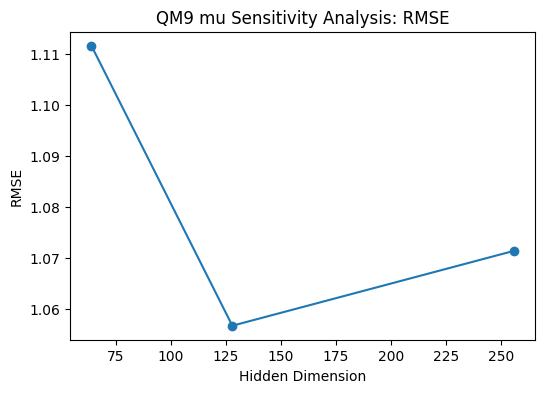

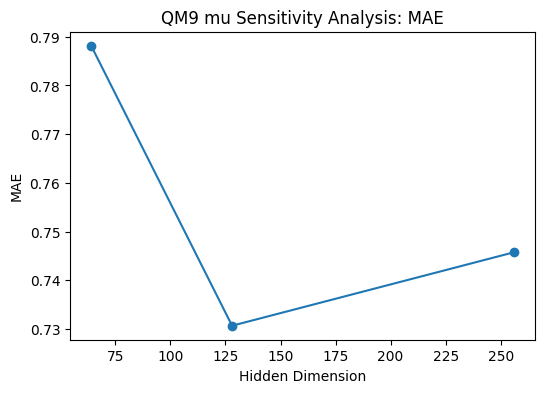

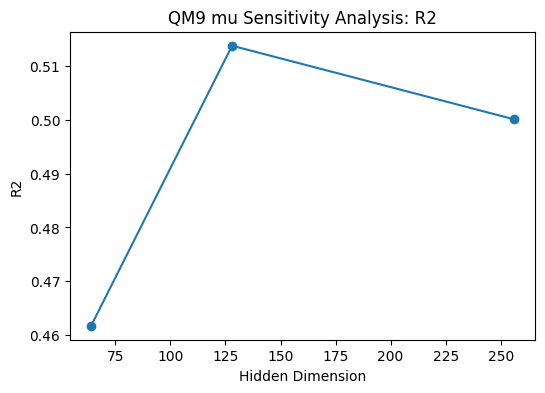

In [66]:
# Sensitivity analysis for hidden dimension
def hidden_dim_sensitivity(loaders, dims=[64, 128, 256], epochs=15):
    rows = []

    for dim in dims:
        model = AttentionGCNRegressor(in_channels, hidden_channels=dim, edge_dim=edge_dim)
        _, _, metrics = fit_regression_model(model, loaders, epochs=epochs)
        rows.append([dim, metrics["RMSE"], metrics["MAE"], metrics["R2"]])

    return pd.DataFrame(rows, columns=["HiddenDim", "RMSE", "MAE", "R2"])

sensitivity_mu = hidden_dim_sensitivity(qm9_mu_loaders)
sensitivity_mu

for metric in ["RMSE", "MAE", "R2"]:
    plt.figure(figsize=(6, 4))
    plt.plot(sensitivity_mu["HiddenDim"], sensitivity_mu[metric], marker="o")
    plt.title(f"QM9 mu Sensitivity Analysis: {metric}")
    plt.xlabel("Hidden Dimension")
    plt.ylabel(metric)
    plt.show()

In [67]:
# Extract embeddings for visualization
def extract_graph_embeddings(model, loader):
    model.eval()
    embeddings = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            if isinstance(model, AttentionGCNRegressor) or isinstance(model, AttentionGCNClassifier):
                x = model.conv1(batch.x, batch.edge_index, batch.edge_attr)
                x = F.relu(x)
                x = model.conv2(x, batch.edge_index, batch.edge_attr)
                x = F.relu(x)
            else:
                continue

            pooled = global_mean_pool(x, batch.batch)
            embeddings.append(pooled.cpu().numpy())
            targets.append(batch.y.view(-1).cpu().numpy())

    return np.vstack(embeddings), np.concatenate(targets)

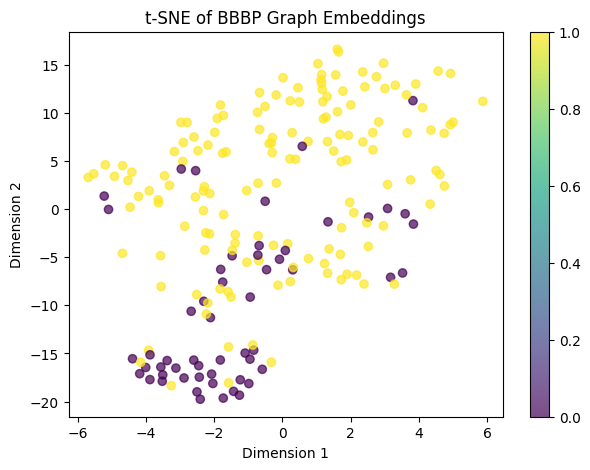

In [68]:
# t-SNE visualization for BBBP embeddings
embeddings_bbbp, labels_bbbp = extract_graph_embeddings(attention_bbbp, bbbp_loaders[2])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(embeddings_bbbp)

plt.figure(figsize=(7, 5))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_bbbp, alpha=0.7)
plt.title("t-SNE of BBBP Graph Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar()
plt.show()

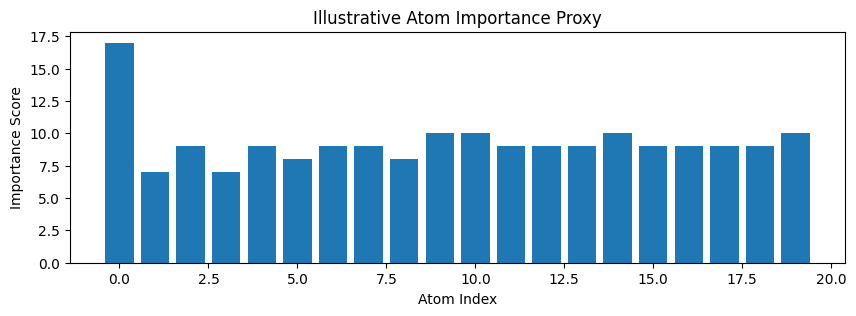

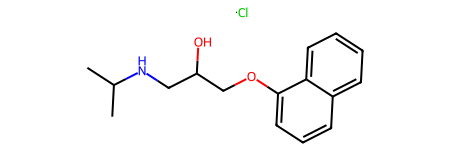

In [71]:
# Simple interpretability proxy for a sample molecule
def atom_importance_proxy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    scores = []
    for atom in mol.GetAtoms():
        score = atom.GetAtomicNum() + atom.GetDegree() + int(atom.GetIsAromatic())
        scores.append(score)

    return mol, scores

sample_smiles = bbbp_df.iloc[0]["smiles"]
mol, scores = atom_importance_proxy(sample_smiles)

plt.figure(figsize=(10, 3))
plt.bar(range(len(scores)), scores)
plt.title("Illustrative Atom Importance Proxy")
plt.xlabel("Atom Index")
plt.ylabel("Importance Score")
plt.show()

mol

In [72]:
# Multi-seed robustness analysis
def run_multiple_seeds_regression(loaders, model_class, seeds=[42, 52, 62], epochs=15):
    rows = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if model_class.__name__ == "AttentionGCNRegressor":
            model = model_class(in_channels, edge_dim=edge_dim)
        else:
            model = model_class(in_channels)

        _, _, metrics = fit_regression_model(model, loaders, epochs=epochs)
        rows.append([seed, metrics["MAE"], metrics["RMSE"], metrics["R2"]])

    df = pd.DataFrame(rows, columns=["Seed", "MAE", "RMSE", "R2"])
    summary = df[["MAE", "RMSE", "R2"]].agg(["mean", "std"])
    return df, summary

seed_runs_mu, seed_summary_mu = run_multiple_seeds_regression(qm9_mu_loaders, AttentionGCNRegressor)
print(seed_runs_mu)
print("\nSummary:")
print(seed_summary_mu)

Epoch 001 | Train Loss: 2.5908 | Val RMSE: 1.3035
Epoch 002 | Train Loss: 1.6786 | Val RMSE: 1.2284
Epoch 003 | Train Loss: 1.5467 | Val RMSE: 1.1741
Epoch 004 | Train Loss: 1.4719 | Val RMSE: 1.1911
Epoch 005 | Train Loss: 1.4391 | Val RMSE: 1.1247
Epoch 006 | Train Loss: 1.3938 | Val RMSE: 1.1177
Epoch 007 | Train Loss: 1.3655 | Val RMSE: 1.0969
Epoch 008 | Train Loss: 1.3518 | Val RMSE: 1.0874
Epoch 009 | Train Loss: 1.3574 | Val RMSE: 1.0847
Epoch 010 | Train Loss: 1.3111 | Val RMSE: 1.0961
Epoch 011 | Train Loss: 1.3162 | Val RMSE: 1.0720
Epoch 012 | Train Loss: 1.2900 | Val RMSE: 1.0878
Epoch 013 | Train Loss: 1.2867 | Val RMSE: 1.0699
Epoch 014 | Train Loss: 1.2554 | Val RMSE: 1.0600
Epoch 015 | Train Loss: 1.2407 | Val RMSE: 1.0509
Epoch 001 | Train Loss: 2.6448 | Val RMSE: 1.3218
Epoch 002 | Train Loss: 1.6966 | Val RMSE: 1.2045
Epoch 003 | Train Loss: 1.4860 | Val RMSE: 1.1589
Epoch 004 | Train Loss: 1.4216 | Val RMSE: 1.1218
Epoch 005 | Train Loss: 1.4282 | Val RMSE: 1.1185


In [73]:
results_reg.to_csv("regression_results.csv", index=False)
results_cls.to_csv("classification_results.csv", index=False)
ablation_results.to_csv("ablation_results.csv", index=False)

torch.save(attention_qm9_mu.state_dict(), "attention_qm9_mu.pt")
torch.save(attention_qm9_homo.state_dict(), "attention_qm9_homo.pt")
torch.save(attention_qm9_u0.state_dict(), "attention_qm9_u0.pt")
torch.save(attention_esol.state_dict(), "attention_esol.pt")
torch.save(attention_lipo.state_dict(), "attention_lipo.pt")
torch.save(attention_bbbp.state_dict(), "attention_bbbp.pt")

print("Files saved.")

Files saved.


In [74]:
# Download saved files from Colab
from google.colab import files

files.download("regression_results.csv")
files.download("classification_results.csv")
files.download("ablation_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>